# Single .fcs File Analysis

Full pipeline: load → compensate → transform → gate → cluster → dimensionality reduction.  
Uses Bioconductor packages: flowCore, ggcyto, FlowSOM, openCyto.

## 1. Setup

In [33]:
library(flowCore)
library(ggcyto)
library(FlowSOM)
library(openCyto)
library(flowWorkspace)
library(ggplot2)
library(uwot)
library(viridis)
library(patchwork)

## 2. Load .fcs file

In [34]:
# -- Point this to your .fcs file --
fcs_path <- "../data/sample.fcs"
ff <- read.FCS(fcs_path, transformation = FALSE, truncate_max_range = FALSE)

ff
cat("\nEvents:", nrow(ff), "\n")
cat("Parameters:", paste(colnames(ff), collapse = ", "), "\n")

flowFrame object 'ad1a9093-aea7-4f1c-a24b-44ee8b230dbb'
with 50000 cells and 11 observables:
        name   desc     range  minRange  maxRange
$P1    FSC-A     NA    262144      0.00    262143
$P2    FSC-H     NA    262144      0.00    262143
$P3    FSC-W     NA    262144      0.00    262143
$P4    SSC-A     NA    262144      0.00    262143
$P5    SSC-H     NA    262144      0.00    262143
$P6    SSC-W     NA    262144      0.00    262143
$P7   FITC-A   CD1a    262144    -99.00    262143
$P8     PE-A   CD83    262144    -93.72    262143
$P9  PerCP-A  CD11b    262144   -111.00    262143
$P10   APC-A     NA    262144    -81.18    262143
$P11    Time     NA    262144      0.00    262143
155 keywords are stored in the 'description' slot


Events: 50000 
Parameters: FSC-A, FSC-H, FSC-W, SSC-A, SSC-H, SSC-W, FITC-A, PE-A, PerCP-A, APC-A, Time 


## 3. Inspect metadata

In [35]:
# Parameter annotations
pData(parameters(ff))

# Keywords of interest
keyword(ff)[grep("SPILL|COMP|DATE|CYT|SRC", names(keyword(ff)), ignore.case = TRUE)]

,name,desc,range,minRange,maxRange
,<I<chr>>,<I<chr>>,<dbl>,<dbl>,<dbl>
$P1,FSC-A,NA,262144,0.00000,262143
$P2,FSC-H,NA,262144,0.00000,262143
$P3,FSC-W,NA,262144,0.00000,262143
$P4,SSC-A,NA,262144,0.00000,262143
$P5,SSC-H,NA,262144,0.00000,262143
$P6,SSC-W,NA,262144,0.00000,262143
$P7,FITC-A,CD1a,262144,-99.00001,262143
$P8,PE-A,CD83,262144,-93.72000,262143
$P9,PerCP-A,CD11b,262144,-111.00000,262143


FITC-A,PE-A,PerCP-A,APC-A
1.0000000000,0.2093023215,0.048625790,0.0000000
0.0189435318,1.0000000000,0.194535516,0.0000000
0.0035758961,0.0039334901,1.000000000,0.1585188
0.0006182816,0.0004946212,0.003462374,1.0000000


## 4. Compensation

In [36]:
# Try to extract spillover matrix from the file
spill <- keyword(ff)$SPILL
if (is.null(spill)) spill <- keyword(ff)$`$SPILLOVER`
if (is.null(spill)) spill <- keyword(ff)$COMP

if (!is.null(spill)) {
    ff_comp <- compensate(ff, spill)
    cat("Compensation applied.\n")
} else {
    ff_comp <- ff
    cat("No spillover matrix found in file — skipping compensation.\n")
    cat("If needed, supply one manually: ff_comp <- compensate(ff, your_matrix)\n")
}

Compensation applied.


## 5. Transformation

Logicle (biexponential) is standard for fluorescence channels. Scatter channels are typically left untransformed.

In [37]:
# Identify fluorescence channels (exclude FSC, SSC, Time)
all_channels <- colnames(ff_comp)
scatter_pattern <- "^(FSC|SSC|Time)"
fluor_channels <- grep(scatter_pattern, all_channels, value = TRUE, invert = TRUE)

cat("Fluorescence channels to transform:", paste(fluor_channels, collapse = ", "), "\n")

# Logicle transformation
lgcl <- estimateLogicle(ff_comp, channels = fluor_channels)
ff_trans <- transform(ff_comp, lgcl)

Fluorescence channels to transform: FITC-A, PE-A, PerCP-A, APC-A 


## 6. Scatter plots — raw vs transformed

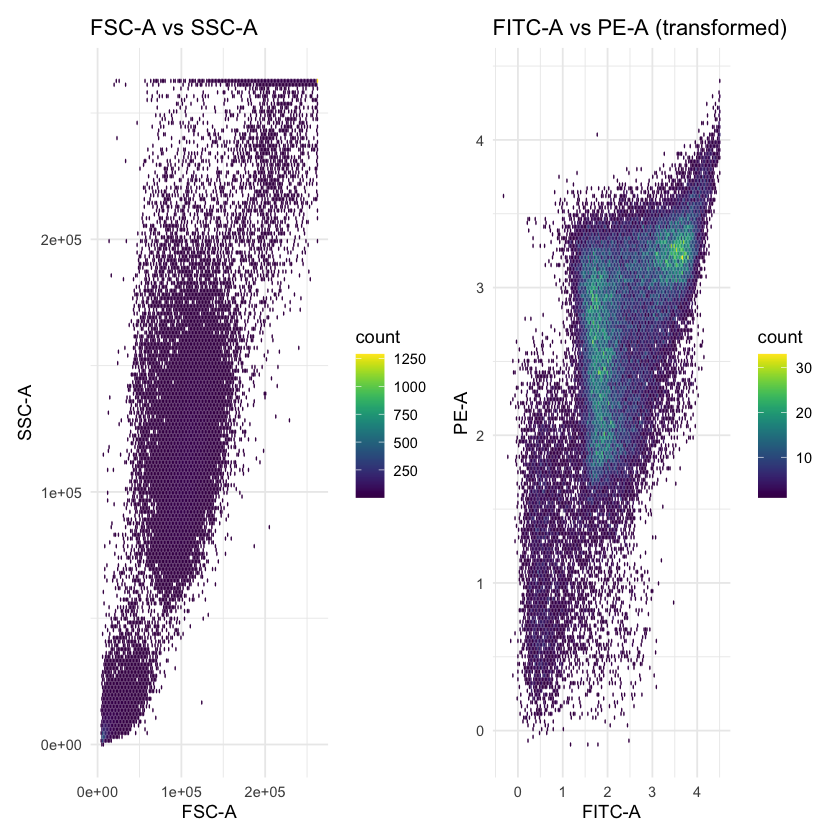

In [38]:
# Pick two fluorescence channels for visualization
if (length(fluor_channels) >= 2) {
    ch1 <- fluor_channels[1]
    ch2 <- fluor_channels[2]
} else {
    ch1 <- fluor_channels[1]
    ch2 <- "SSC-A"
}

# Transformed data as data.frame
df_trans <- as.data.frame(exprs(ff_trans))

p1 <- ggplot(df_trans, aes(x = .data[[ch1]], y = .data[[ch2]])) +
    geom_hex(bins = 150) +
    scale_fill_viridis() +
    theme_minimal() +
    labs(title = paste(ch1, "vs", ch2, "(transformed)"))

p2 <- ggplot(df_trans, aes(x = `FSC-A`, y = `SSC-A`)) +
    geom_hex(bins = 150) +
    scale_fill_viridis() +
    theme_minimal() +
    labs(title = "FSC-A vs SSC-A")

p2 + p1

## 7. Manual gating with flowWorkspace

In [39]:
# Create a GatingSet from the flowFrame
gs <- GatingSet(flowSet(ff_trans))

# Gate 1: Scatter gate (debris removal)
# -- Adjust coordinates to your data --
scatter_gate <- rectangleGate(
    filterId = "nonDebris",
    "FSC-A" = c(50000, 250000),
    "SSC-A" = c(5000, 200000)
)

gs_pop_add(gs, scatter_gate, parent = "root")
recompute(gs)

gs_get_pop_paths(gs)
gs_pop_get_stats(gs)

[1] 2

done!



[1] "root"       "/nonDebris"

sample,pop,count
<chr>,<chr>,<dbl>
V1,root,50000
V1,/nonDebris,34742


In [ ]:
# Visualize the scatter gate — bivariate + 1D marginals with gate cutoffs
# Pattern from openCyto's HowToAutoGating vignette: ggcyto + geom_gate + geom_stats
options(repr.plot.width = 11, repr.plot.height = 8)

g_bivar <- ggcyto(gs, aes(x = `FSC-A`, y = `SSC-A`)) +
    geom_hex(bins = 150) +
    geom_gate("nonDebris") +
    geom_stats(adjust = 0.8) +
    scale_fill_viridis() +
    ggtitle("Scatter gate (nonDebris)") +
    theme_bw()

# 1D density profiles with gate cutoffs — shows what's removed in each axis
df_raw <- as.data.frame(exprs(ff_trans))
df_raw$kept <- df_raw$`FSC-A` >= 50000 & df_raw$`FSC-A` <= 250000 &
               df_raw$`SSC-A` >= 5000  & df_raw$`SSC-A` <= 200000

g_fsc <- ggplot(df_raw, aes(x = `FSC-A`, fill = kept)) +
    geom_density(alpha = 0.5) +
    geom_vline(xintercept = c(50000, 250000), linetype = "dashed", color = "red") +
    scale_fill_manual(values = c("TRUE" = "#1f77b4", "FALSE" = "grey70"),
                      labels = c("removed", "kept")) +
    theme_bw() + ggtitle("FSC-A density (red = gate cutoffs)")

g_ssc <- ggplot(df_raw, aes(x = `SSC-A`, fill = kept)) +
    geom_density(alpha = 0.5) +
    geom_vline(xintercept = c(5000, 200000), linetype = "dashed", color = "red") +
    scale_fill_manual(values = c("TRUE" = "#1f77b4", "FALSE" = "grey70"),
                      labels = c("removed", "kept")) +
    theme_bw() + ggtitle("SSC-A density")

as.ggplot(g_bivar) / (g_fsc + g_ssc) + plot_layout(heights = c(2, 1))


## 8. Automated gating with openCyto (optional)

In [ ]:
# Automated 1D gating with openCyto::gate_mindensity
# Finds the valley between negative and positive populations on a marker.
# Inspired by the openCyto HowToAutoGating vignette (density + cutpoint),
# but built with pure ggplot to avoid ggcyto S4 dispatch issues in notebooks.

gate_channel <- fluor_channels[1]
parent_data  <- gs_pop_get_data(gs, "nonDebris")[[1]]

g <- tryCatch(
    openCyto::gate_mindensity(
        parent_data,
        channel  = gate_channel,
        filterId = paste0(gate_channel, "_pos")
    ),
    error = function(e) { message("gate_mindensity failed: ", conditionMessage(e)); NULL }
)

if (!is.null(g)) {
    pos_name <- paste0(gate_channel, "_pos")
    if (pos_name %in% basename(gs_get_pop_paths(gs))) {
        gs_pop_remove(gs, pos_name)
    }
    gs_pop_add(gs, g, parent = "nonDebris")
    recompute(gs)

    cutoff   <- as.numeric(g@min[gate_channel])
    ch2      <- if (length(fluor_channels) >= 2) fluor_channels[2] else "SSC-A"
    df_gated <- as.data.frame(exprs(parent_data))
    df_gated$pos <- df_gated[[gate_channel]] >= cutoff
    pct_pos  <- 100 * mean(df_gated$pos)

    # --- Sanity check: is the distribution actually bimodal around the cutoff? ---
    d <- density(df_gated[[gate_channel]], adjust = 1.5)
    peak_idx  <- which(diff(sign(diff(d$y))) == -2) + 1
    sig_peaks <- peak_idx[d$y[peak_idx] >= 0.05 * max(d$y)]   # ≥5% of max height
    n_modes   <- length(sig_peaks)
    valley_idx <- which(diff(sign(diff(d$y))) ==  2) + 1
    near_valley <- length(valley_idx) > 0 &&
        min(abs(d$x[valley_idx] - cutoff)) < 0.1 * diff(range(d$x))

    cat(sprintf("Gate diagnostics for %s:\n", gate_channel))
    cat(sprintf("  cutoff       = %.3f\n", cutoff))
    cat(sprintf("  %% positive   = %.1f%% of parent\n", pct_pos))
    cat(sprintf("  density modes = %d  (peaks at: %s)\n",
                n_modes, paste(sprintf("%.2f", d$x[sig_peaks]), collapse = ", ")))
    if (n_modes >= 2 && near_valley) {
        cat("  verdict: GOOD — clear bimodal split, cutoff lies near a valley.\n")
    } else if (n_modes >= 2) {
        cat("  verdict: CHECK — bimodal but cutoff is not near a valley.\n")
    } else {
        cat("  verdict: WEAK — distribution is unimodal; mindensity may be unreliable.\n")
        cat("  → consider a manual gate or a quantile-based threshold.\n")
    }

    # --- Plots: side-by-side density + 2D scatter ---
    options(repr.plot.width = 12, repr.plot.height = 5)

    p_density <- ggplot(df_gated, aes(x = .data[[gate_channel]])) +
        geom_density(fill = "grey80", color = "black", linewidth = 0.4) +
        geom_vline(xintercept = cutoff, color = "red", linetype = "dashed", linewidth = 0.8) +
        annotate("text", x = cutoff, y = max(d$y) * 0.9,
                 label = sprintf(" cutoff = %.2f", cutoff),
                 hjust = 0, color = "red", size = 3.8) +
        ggtitle(sprintf("mindensity cutpoint on %s", gate_channel)) +
        theme_bw()

    p_scatter <- ggplot(df_gated, aes(x = .data[[gate_channel]], y = .data[[ch2]])) +
        geom_hex(bins = 120) +
        geom_vline(xintercept = cutoff, color = "red", linetype = "dashed", linewidth = 0.8) +
        scale_fill_viridis() +
        ggtitle(sprintf("%s (%.1f%% positive) — %s vs %s",
                        pos_name, pct_pos, gate_channel, ch2)) +
        theme_bw()

    print(p_density + p_scatter)
}

# Hierarchy + per-population percentages
options(repr.plot.width = 6, repr.plot.height = 4)
plot(gs)
gs_pop_get_stats(gs, type = "percent")


## 9. FlowSOM clustering

In [42]:
# Extract gated population
gated_data <- gs_pop_get_data(gs, "nonDebris")[[1]]

# Run FlowSOM on fluorescence channels
fsom <- FlowSOM(
    gated_data,
    colsToUse = fluor_channels,
    nClus = 10,      # meta-clusters
    xdim = 10,
    ydim = 10,
    seed = 42
)

# Get cluster assignments
meta_clusters <- GetMetaclusters(fsom)
cat("Meta-cluster sizes:\n")
table(meta_clusters)

Meta-cluster sizes:


meta_clusters
    1     2     3     4     5     6     7     8     9    10 
10196    96    91  2147  8401   133   958   940  2638  9142 

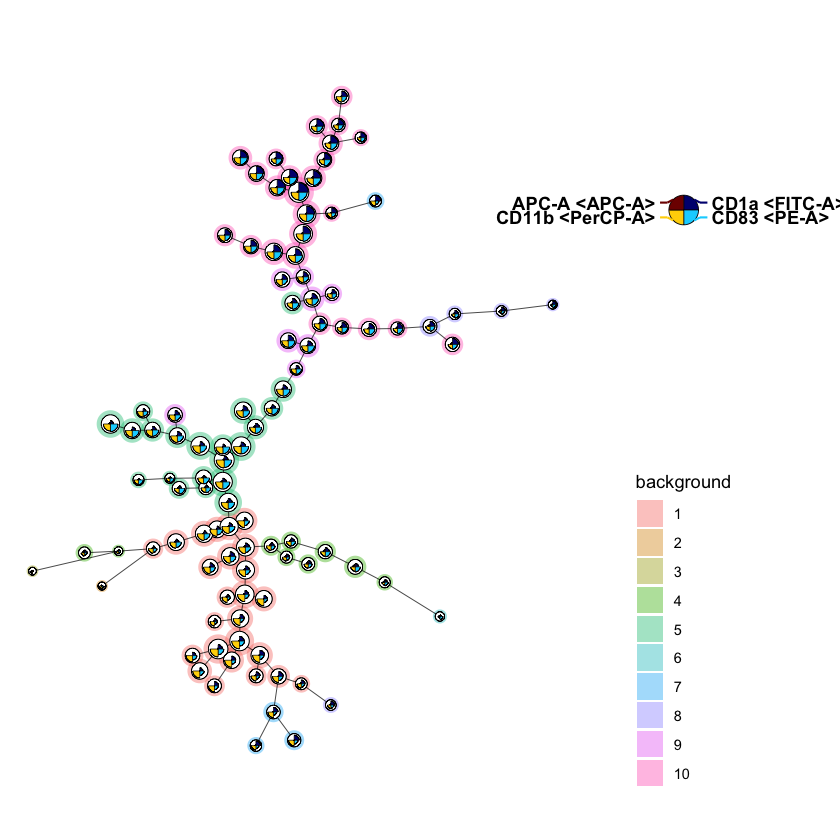

In [43]:
# FlowSOM tree — backgroundValues needs one value per SOM node (not per cell)
PlotStars(fsom, backgroundValues = fsom$metaclustering)

## 10. UMAP

In [44]:
mat <- exprs(gated_data)[, fluor_channels]
mat_scaled <- scale(mat)

set.seed(42)
n_sub <- min(nrow(mat_scaled), 10000)
idx <- sample(nrow(mat_scaled), n_sub)

umap_res <- uwot::umap(mat_scaled[idx, ], n_neighbors = 15, min_dist = 0.2)

umap_df <- data.frame(
    UMAP1 = umap_res[, 1],
    UMAP2 = umap_res[, 2],
    cluster = factor(meta_clusters[idx])
)

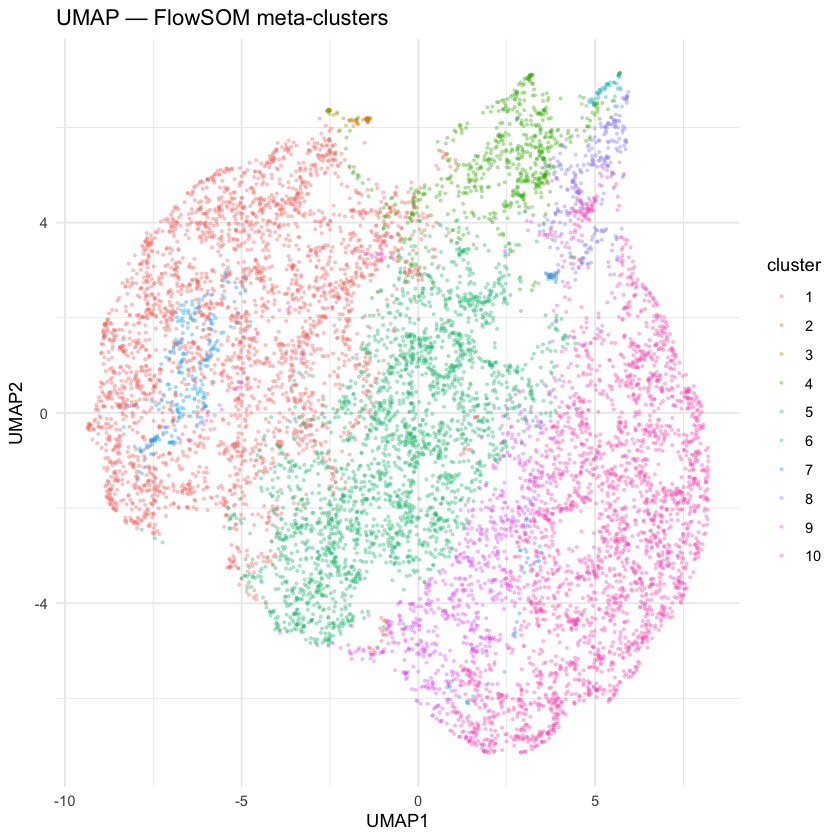

In [45]:
ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = cluster)) +
    geom_point(alpha = 0.3, size = 0.5) +
    theme_minimal() +
    labs(title = "UMAP — FlowSOM meta-clusters")

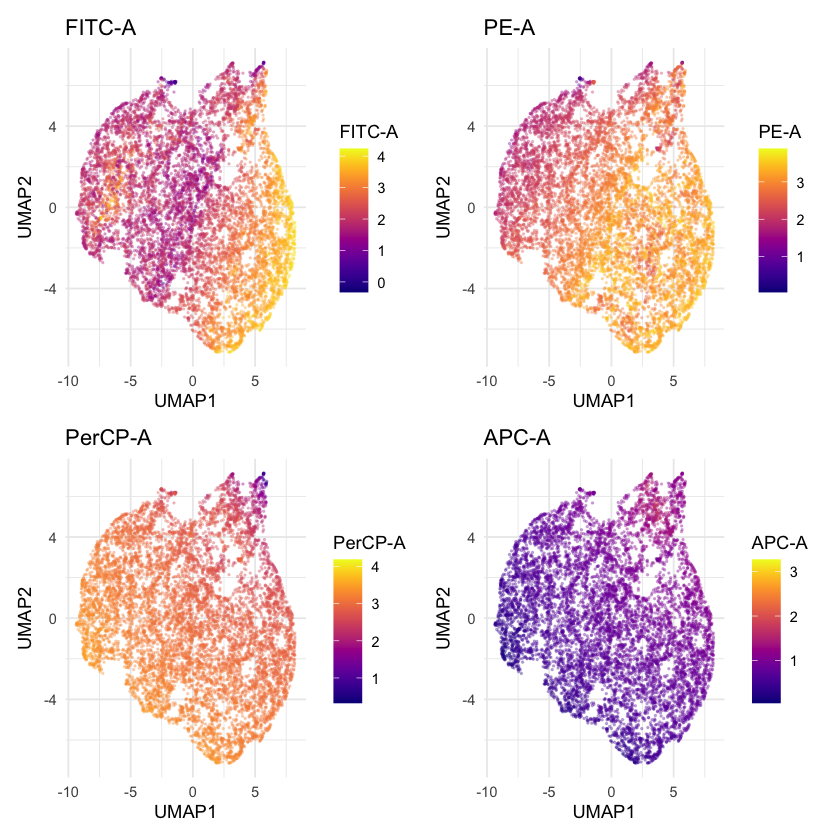

In [46]:
# Color by marker intensity
for (ch in fluor_channels) {
    umap_df[[ch]] <- mat[idx, ch]
}

plots <- lapply(fluor_channels, function(ch) {
    ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = .data[[ch]])) +
        geom_point(alpha = 0.3, size = 0.3) +
        scale_color_viridis(option = "C") +
        theme_minimal() +
        labs(title = ch)
})

wrap_plots(plots)

## 11. Summary statistics

In [47]:
# Population stats
pop_stats <- gs_pop_get_stats(gs, type = "count")
pop_stats$percent <- pop_stats$count / pop_stats$count[1] * 100
pop_stats

# Cluster MFIs
cluster_mfi <- aggregate(mat[idx, ], by = list(cluster = meta_clusters[idx]), FUN = median)
cluster_mfi

sample,pop,count,percent
<chr>,<chr>,<dbl>,<dbl>
V1,root,50000,100.000
V1,/nonDebris,34742,69.484
V1,/nonDebris/FITC-A_pos,9839,19.678


cluster,FITC-A,PE-A,PerCP-A,APC-A
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.8390201,2.2572103,3.105745,0.6822898
2,0.6741665,2.3119853,2.631744,0.9873807
3,0.9849907,0.8882515,2.603274,1.0130526
4,2.0391867,2.5106170,2.576488,1.2675323
5,1.8143876,3.0276123,3.032924,0.7729869
6,1.3939857,2.5512766,1.501398,1.1507549
7,3.0103800,2.1527362,3.178219,0.5988362
8,2.8152603,2.6766757,2.308873,1.1975769
9,2.5809708,3.0672002,3.133203,0.6654940


## 12. Save results

In [48]:
out_dir <- "../data/results"
dir.create(out_dir, showWarnings = FALSE)

# Subsampled gated events with cluster assignments and UMAP coords
gated_export <- as.data.frame(exprs(gated_data)[idx, ])
gated_export$cluster <- meta_clusters[idx]
gated_export$UMAP1  <- umap_df$UMAP1
gated_export$UMAP2  <- umap_df$UMAP2

write.csv(gated_export,  file.path(out_dir, "02_gated_clustered.csv"), row.names = FALSE)
write.csv(pop_stats,     file.path(out_dir, "02_population_stats.csv"), row.names = FALSE)
write.csv(cluster_mfi,   file.path(out_dir, "02_cluster_mfi.csv"),     row.names = FALSE)
cat("Saved to", out_dir, "\n")

Saved to ../data/results 
